# Project 03 (final) — reference solution: explaining and predicting demand

**Scenario (continuing from module 02):** two questions from the management of Capital
Bikeshare — how strongly does daily demand depend on weather and calendar (regression),
and how many bikes will be needed tomorrow (time series forecast)?

**Data: real** — the bike sharing data (UCI) at the **daily level** (`day.csv`,
731 days 2011-2012).

**This is the fully worked solution.** All cells have been executed.

**Reference to the script:** sections 1.1-1.2, 2.1, 2.2 (leakage!).

## 1. Loading the data

De-normalisation as before (`temp*41` = degrees C etc. — reading the documentation pays off).

(731, 19)


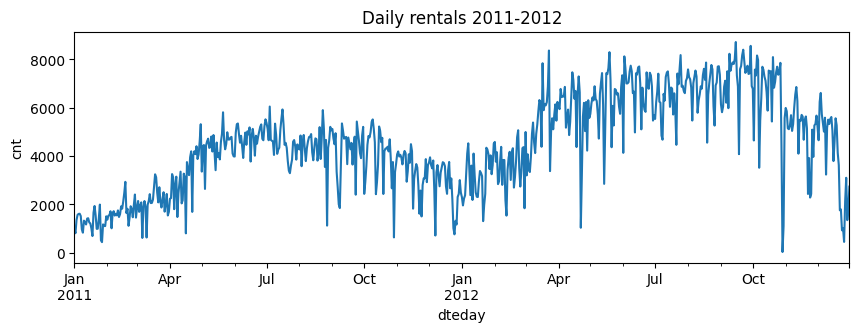

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

PATH = "datasets/day.csv" if os.path.exists("datasets/day.csv") else "../datasets/day.csv"
df = pd.read_csv(PATH, parse_dates=["dteday"])
df["temp_c"] = df["temp"] * 41
df["hum_pct"] = df["hum"] * 100
df["wind_kmh"] = df["windspeed"] * 67
print(df.shape)

df.set_index("dteday")["cnt"].plot(figsize=(10, 3), title="Daily rentals 2011-2012")
plt.ylabel("cnt"); plt.show()

## 2. Simple regression: demand ~ temperature

**Tasks:**
1. Fit `cnt ~ temp_c` with `LinearRegression` (careful: sklearn expects X as 2D —
   `df[["temp_c"]]`, not `df["temp_c"]`).
2. Print the slope, intercept and $R^2$ and formulate the slope as a sentence
   ("per degree more ...").
3. Draw a scatter plot plus the regression line.

Slope: 162.0 rentals per degree C
Intercept: 1215
R2: 0.394


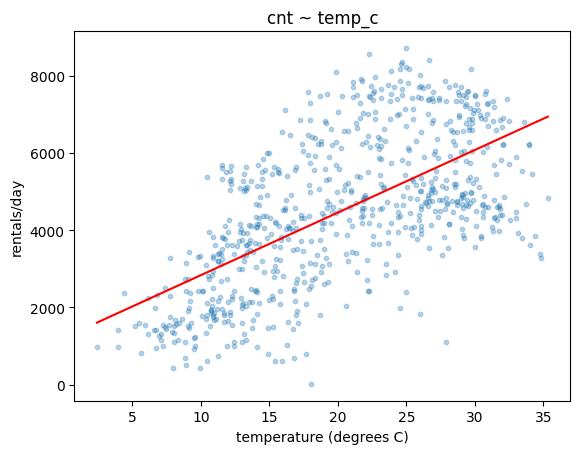

True


In [2]:
X1 = df[["temp_c"]]
y = df["cnt"]
m1 = LinearRegression().fit(X1, y)
print(f"Slope: {m1.coef_[0]:.1f} rentals per degree C")
print(f"Intercept: {m1.intercept_:.0f}")
print(f"R2: {m1.score(X1, y):.3f}")

ordered = X1.sort_values("temp_c")
plt.scatter(df["temp_c"], y, alpha=0.3, s=10)
plt.plot(ordered["temp_c"], m1.predict(ordered), color="red")
plt.xlabel("temperature (degrees C)"); plt.ylabel("rentals/day"); plt.title("cnt ~ temp_c")
plt.show()

# Mini check: R2 is about r^2 from module 02 (r was 0.627)
print(0.35 < m1.score(X1, y) < 0.45)

## 3. Residual analysis — keeping an eye on the model

**Task:** plot the residuals ($y - \hat{y}$) against the temperature.
Do you see a curvature? What does it mean substantively? (Script 1.1: residual plot!)

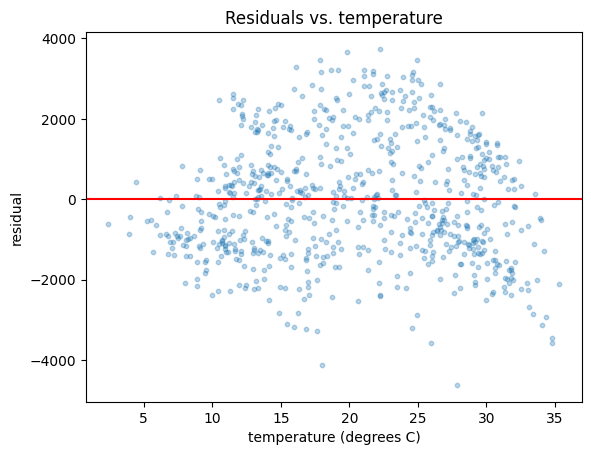

In [3]:
residuals = y - m1.predict(X1)
plt.scatter(df["temp_c"], residuals, alpha=0.3, s=10)
plt.axhline(0, color="red")
plt.xlabel("temperature (degrees C)"); plt.ylabel("residual"); plt.title("Residuals vs. temperature")
plt.show()

**Finding:** an inverted U shape — at mild temperatures the line underestimates,
on very hot days it overestimates. Substantively clear: **above about 30 degrees, cycling
stops being fun.** A straight line cannot represent "first up, then down".

**Task:** add `temp_c2 = temp_c**2` as a feature and fit `cnt ~ temp_c + temp_c2`.
Compare $R^2$ and compute the **vertex** $-\beta_1 / (2\beta_2)$ — the computed
comfort temperature.

In [4]:
df["temp_c2"] = df["temp_c"] ** 2
X2 = df[["temp_c", "temp_c2"]]
m2 = LinearRegression().fit(X2, y)
vertex = -m2.coef_[0] / (2 * m2.coef_[1])
print(f"R2 linear: {m1.score(X1, y):.3f}  ->  quadratic: {m2.score(X2, y):.3f}")
print(f"Comfort temperature (vertex): {vertex:.1f} degrees C")

# Mini check:
print(25 < vertex < 31)

R2 linear: 0.394  ->  quadratic: 0.453
Comfort temperature (vertex): 29.1 degrees C
True


## 4. Multiple regression: the explanatory model

**Task:** fit `cnt ~ temp_c + temp_c2 + hum_pct + wind_kmh + workingday + yr`
and interpret EVERY coefficient in one sentence — **ceteris paribus** (script 1.2!).
`yr` is particularly interesting (0 = 2011, 1 = 2012): what does it measure?

In [5]:
EXPLANATORY_FEATURES = ["temp_c", "temp_c2", "hum_pct", "wind_kmh", "workingday", "yr"]
m3 = LinearRegression().fit(df[EXPLANATORY_FEATURES], y)
print(f"R2: {m3.score(df[EXPLANATORY_FEATURES], y):.3f}\n")
for name, coef in zip(EXPLANATORY_FEATURES, m3.coef_):
    print(f"{name:>12}: {coef:>9.1f}")

R2: 0.794

      temp_c:     555.9
     temp_c2:     -10.0
     hum_pct:     -32.3
    wind_kmh:     -77.0
  workingday:      97.7
          yr:    1893.1


**Reference interpretation (compare with yours):**

- `hum_pct` about −32: per percentage point of humidity, about 32 fewer rentals (other conditions equal)
- `wind_kmh` about −77: wind is a clear deterrent
- `workingday` about +98: working days bring somewhat more volume at the daily level (the commuters!)
- `yr` about +1893: **in 2012 the days were on average about 1900 rentals above 2011** — this
  is the growth trend as a number. Without `yr` this trend would "seep" into the other
  coefficients (omitted variable bias!)
- Interpreting `temp_c`/`temp_c2` individually is pointless (the multicollinearity between
  $x$ and $x^2$ is intended here) — they act only *together*, as a parabola.

**A warning against causal talk:** "+98 on working days" is a *description* of the data,
not an experiment. For causal statements we lack confounder control and randomisation.

## 5. Forecasting: knowing in the morning what will be missing tonight

Now the switch from **explaining** to **predicting** — with the rules from script 2.1/2.2:

- **Lag features:** `lag1` (yesterday), `lag7` (a week ago), `roll7`
  (mean of the last 7 days, shifted by one day — why that needs the `.shift(1)` is the
  leakage question below!)
- **Temporal split:** training up to 30 September 2012, test from 1 October 2012 (92 days)
- **Baselines first:** naive (= yesterday) and seasonal naive (= 7 days ago)
- **Metric:** MAE (mean absolute error — directly interpretable in "bikes")

**Task:** build the three lag features, split temporally, compute the MAE of the two
baselines and then train a `LinearRegression` on weather + calendar + lags. Does it beat
the baselines?

In [6]:
df["lag1"] = df["cnt"].shift(1)
df["lag7"] = df["cnt"].shift(7)
df["roll7"] = df["cnt"].shift(1).rolling(7).mean()
dd = df.dropna().reset_index(drop=True)

FEATURES = EXPLANATORY_FEATURES + ["lag1", "lag7", "roll7"]
train = dd[dd["dteday"] < "2012-10-01"]
test = dd[dd["dteday"] >= "2012-10-01"]

mae_naive = mean_absolute_error(test["cnt"], test["lag1"])
mae_seasonal = mean_absolute_error(test["cnt"], test["lag7"])

model = LinearRegression().fit(train[FEATURES], train["cnt"])
forecast = model.predict(test[FEATURES])
mae_model = mean_absolute_error(test["cnt"], forecast)

print(f"Test period: {len(test)} days")
print(f"MAE naive (yesterday):      {mae_naive:7.0f} bikes")
print(f"MAE seasonal (7 days ago):  {mae_seasonal:7.0f} bikes")
print(f"MAE regression model:       {mae_model:7.0f} bikes")

# Mini check: the model beats both baselines
print(mae_model < mae_naive < mae_seasonal)

Test period: 92 days
MAE naive (yesterday):          952 bikes
MAE seasonal (7 days ago):     1458 bikes
MAE regression model:           859 bikes
True


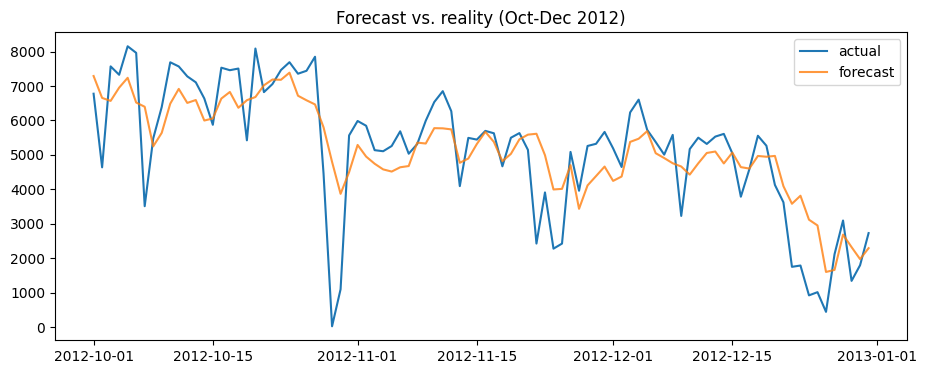

,dteday,cnt,error,weathersit
660,2012-10-29,22,4776.454979,3
684,2012-11-22,2425,3189.732578,1
638,2012-10-07,3510,2888.788350,2


In [7]:
plt.figure(figsize=(11, 4))
plt.plot(test["dteday"], test["cnt"].values, label="actual")
plt.plot(test["dteday"], forecast, label="forecast", alpha=0.8)
plt.title("Forecast vs. reality (Oct-Dec 2012)"); plt.legend(); plt.show()

worst = test.assign(error=(test["cnt"] - forecast).abs()).nlargest(3, "error")
worst[["dteday", "cnt", "error", "weathersit"]]

**Look at the worst days:** at the end of October 2012 demand collapses to almost
zero — that is **Hurricane Sandy** (29/30 October 2012, Washington D.C. came to a
standstill). No model in the world predicts such a thing from lag features. Real forecasts
therefore need external information (weather warnings, events) — and honest error figures
that include such days.

## 6. The leakage demo: why the temporal split is not negotiable

**Task:** train the same model with a **random** 75/25 split (`train_test_split`,
`random_state=0`) and compare the test MAE with your temporal split. Explain the
difference. (Script 2.2: leakage!)

In [8]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(dd[FEATURES], dd["cnt"], test_size=0.25, random_state=0)
m_random = LinearRegression().fit(X_tr, y_tr)
mae_random = mean_absolute_error(y_te, m_random.predict(X_te))
print(f"MAE temporal split: {mae_model:.0f}")
print(f"MAE random split:   {mae_random:.0f}  <- looks better, but it is a lie!")

MAE temporal split: 859
MAE random split:   625  <- looks better, but it is a lie!


**Explanation:** with the random split, training days lie temporally BETWEEN the
test days — for a test day the model often knows the previous and the following day from
training, and the lag features carry their information straight in. The roughly 625 are
not forecasting performance but a measurement artefact. The honest value is the temporal
split (about 860): **that is how good we really would have been had we forecast every day
from October 2012 onwards.**

## 7. Conclusion for management

**Task:** again 4-5 bullet points in everyday language: what drives demand (with numbers!),
how well can we predict tomorrow, where are the limits?

<details><summary>Reference conclusion</summary>

- Temperature is the strongest lever: demand rises up to about 28 degrees and falls above that — hot days are NOT peak days.
- Wind and high humidity noticeably depress demand (about 77 and about 32 rentals per unit respectively).
- The business grew in 2012 by about 1,900 rentals per day on average compared with 2011 — capacity planning has to extrapolate this trend.
- Our daily forecast is on average about 860 bikes off (with 2,000-8,000 rentals per day) and beats simple rules of thumb ("like yesterday": about 950).
- Limits: extreme events (Hurricane Sandy) cannot be predicted from historical patterns — such days need weather warnings in the process.
</details>

## Done — what you can do now

- regression as an explanatory tool: read coefficients ceteris paribus, place $R^2$ in
  context, check residuals, capture non-linearity with a quadratic term
- regression as a forecasting tool: lag features, temporal split, baselines, MAE
- not just name leakage but **demonstrate it in numbers**
- communicate the limits of a model honestly (Sandy!)

**Bonus tasks:**
1. Sin/cos encoding of the month (script 2.2) instead of `yr` + season dummies — does it help?
2. Compute the MAE separately for October/November/December — does the forecast get worse towards the end of the year? Why might that be?
3. Standardise the features and compare the coefficients — which variable now has the largest magnitude, and why is that the fairer basis for comparison?

---

**Module 03 is thereby complete.** Next comes Machine Learning 1 — where "fitting a
regression" becomes a systematic toolbox with validation, regularisation and many more
model families.